# Gaming Behavior and Academic Performance: Exploratory Data Analysis

This notebook investigates associations between gaming behavior, study habits, lifestyle
characteristics, and academic grades. It follows an evidence-based cleaning process, preserves
the raw file, and treats the continuous `grades` variable as the target of a regression-style
exploratory analysis.

## Dataset Understanding

### 1. What is the dataset about?

The dataset explores the relationship between students' gaming behavior, lifestyle habits, and academic performance.

It includes information such as gaming hours, study hours, sleep hours, attendance, device usage, stress level, addiction score, and grades.

### 2. What does each row (record) represent?

Each row represents one student and contains their gaming, lifestyle, and academic information.

### 3. How many rows and columns are there?

The original dataset contains:

- 8,000 rows
- 14 columns

### 4. How many numerical and categorical features are there?

The dataset contains:

- 10 numerical features
- 3 categorical features
- 1 identifier column: `student_id`

The categorical features are:

- `gender`
- `gaming_genre`
- `stress_level`

The `student_id` column is an identifier and is not used as a numerical feature.

### 5. What is the target feature?

The target feature is `grades`.

It represents the student's academic performance and is a continuous numerical variable.

### 6. What were the initial observations about the data?

The initial observations were:

- The dataset is well structured and easy to inspect.
- There were no original missing values.
- There were no duplicate rows or duplicate student IDs.
- Most columns had suitable data types.
- The `student_id` column needed to be converted from a number to a string.
- The categorical columns needed to be converted to the `category` data type.
- Some values in `grades` were outside the valid range of 0 to 100.
- Some values in `addiction_score` were negative.
- The categorical values were written consistently, with no hidden differences in capitalization or spacing.
- The exact meaning of some features, such as `stress_level` and the scale of `addiction_score`, requires clearer source documentation.

In [1]:
# Import the analysis stack and load an untouched source copy.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("Gaming_Academic_Performance.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path(
        "/Users/anas/Desktop/AdvTuwaiq/unit 2 /project/"
        "Gaming_Academic_Performance.csv"
    )

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

# Scope restriction: this analysis compares Male and Female students only.
GENDER_SCOPE = ["Male", "Female"]
rows_before_gender_scope = len(df)
df = df[df["gender"].isin(GENDER_SCOPE)].reset_index(drop=True)
rows_removed_by_gender_scope = rows_before_gender_scope - len(df)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

print(f"Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns from {DATA_PATH.resolve()}.")
print(
    f"Gender scope restricted to {' / '.join(GENDER_SCOPE)}: "
    f"removed {rows_removed_by_gender_scope:,} rows; "
    f"{len(df):,} rows remain in the working frame."
)

Loaded 8,000 rows and 14 columns from /Users/anas/Desktop/AdvTuwaiq/unit 2 /project/Gaming_Academic_Performance.csv.
Gender scope restricted to Male / Female: removed 293 rows; 7,707 rows remain in the working frame.


## Part 1 — Dataset Understanding

The dataset is intended to investigate how students' gaming behavior, study habits, lifestyle
factors, and academic performance are associated. Each row appears to represent one student.
The source file has **8,000 rows and 14 columns**. This analysis is scoped to a two-group
gender comparison, so the 293 records labelled `Other` are excluded at load time and the
working frame holds **7,707 rows**, as confirmed by the setup output. The numerical
features are `age`, `gaming_hours`, `study_hours`, `sleep_hours`, `attendance`,
`social_activity`, `device_usage`, `reaction_time_ms`, and `addiction_score`; `student_id` is
stored numerically but is an identifier, not an analytical measure. The categorical features
are `gender`, `gaming_genre`, and `stress_level`. The target is `grades`, a continuous numerical
variable, so this is a regression-style analytical problem rather than a classification task.

### Data dictionary

The dictionary below records the stored type and the analytical meaning used in this notebook.
Where source documentation is unavailable, the scale is explicitly marked as uncertain rather
than guessed.

In [ ]:
# Build a reader-facing data dictionary from the loaded schema.
dictionary_details = {
    "student_id": ("Unique student identifier", "Sequential ID", "Identifier"),
    "age": ("Student age", "Years", "Feature"),
    "gender": (
        "Reported gender",
        "Source: Male / Female / Other; analysis scope: Male / Female",
        "Feature",
    ),
    "gaming_hours": ("Time spent gaming", "Hours; source time window undocumented", "Feature"),
    "study_hours": ("Time spent studying", "Hours; source time window undocumented", "Feature"),
    "sleep_hours": ("Time spent sleeping", "Hours; source time window undocumented", "Feature"),
    "attendance": ("Class attendance", "Percentage, 0–100", "Feature"),
    "gaming_genre": ("Primary gaming genre", "FPS / Casual / RPG", "Feature"),
    "social_activity": ("Social activity measure", "0–5; source unit undocumented", "Feature"),
    "device_usage": ("Overall device-use measure", "Hours; source time window undocumented", "Feature"),
    "reaction_time_ms": ("Measured reaction time", "Milliseconds", "Feature"),
    "addiction_score": (
        "Gaming-addiction measure",
        "uncertain — undocumented composite score; validated below",
        "Feature",
    ),
    "stress_level": ("Reported stress category", "Low / Medium / High", "Feature"),
    "grades": ("Academic grade", "Assumed percentage, 0–100; requires source confirmation", "Target"),
}

data_dictionary = pd.DataFrame(
    [
        {
            "column": column,
            "description": dictionary_details[column][0],
            "dtype": str(df_raw[column].dtype),
            "unit_or_scale": dictionary_details[column][1],
            "role": dictionary_details[column][2],
        }
        for column in df_raw.columns
    ]
)
display(data_dictionary)

,column,description,dtype,unit_or_scale,role
0,student_id,Unique student identifier,int64,Sequential ID,Identifier
1,age,Student age,int64,Years,Feature
2,gender,Reported gender,object,Source: Male / Female / Other; analysis scope:...,Feature
3,gaming_hours,Time spent gaming,float64,Hours; source time window undocumented,Feature
4,study_hours,Time spent studying,float64,Hours; source time window undocumented,Feature
5,sleep_hours,Time spent sleeping,float64,Hours; source time window undocumented,Feature
6,attendance,Class attendance,float64,"Percentage, 0–100",Feature
7,gaming_genre,Primary gaming genre,object,FPS / Casual / RPG,Feature
8,social_activity,Social activity measure,float64,0–5; source unit undocumented,Feature
9,device_usage,Overall device-use measure,float64,Hours; source time window undocumented,Feature


## Part 2 — Initial Exploration

The first pass inspects dimensions, column names, sample records, stored types, summary
statistics, categorical summaries, and cardinality. Each concern is kept in a small,
reproducible cell.

In [3]:
# Confirm the source dimensions.
df.shape

(7707, 14)

In [4]:
# List source columns in their stored order.
df.columns.tolist()

['student_id',
 'age',
 'gender',
 'gaming_hours',
 'study_hours',
 'sleep_hours',
 'attendance',
 'gaming_genre',
 'social_activity',
 'device_usage',
 'reaction_time_ms',
 'addiction_score',
 'stress_level',
 'grades']

In [5]:
# Preview a bounded sample of records.
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [6]:
# Inspect stored types and non-null counts.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7707 entries, 0 to 7706
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        7707 non-null   int64  
 1   age               7707 non-null   int64  
 2   gender            7707 non-null   object 
 3   gaming_hours      7707 non-null   float64
 4   study_hours       7707 non-null   float64
 5   sleep_hours       7707 non-null   float64
 6   attendance        7707 non-null   float64
 7   gaming_genre      7707 non-null   object 
 8   social_activity   7707 non-null   float64
 9   device_usage      7707 non-null   float64
 10  reaction_time_ms  7707 non-null   float64
 11  addiction_score   7707 non-null   float64
 12  stress_level      7707 non-null   object 
 13  grades            7707 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 843.1+ KB


In [39]:
# Summarize analytical numerical columns; exclude the identifier explicitly.
df.drop(columns="student_id").describe().T

,count,mean,std,min,25%,50%,75%,max
age,7707.0,19.976255,2.590251,16.00,18.000,20.000000,22.000,24.00
gaming_hours,7707.0,4.088425,2.309694,0.00,2.120,4.130000,6.070,8.00
study_hours,7707.0,5.467535,2.574870,1.00,3.255,5.470000,7.665,10.00
sleep_hours,7707.0,6.493597,1.441629,4.00,5.240,6.510000,7.730,9.00
attendance,7707.0,79.855847,11.568373,60.00,69.790,79.600000,90.045,100.00
social_activity,7707.0,2.509098,1.442519,0.00,1.280,2.500000,3.760,5.00
device_usage,7707.0,7.585274,2.706125,1.10,5.560,7.610000,9.590,13.95
reaction_time_ms,7707.0,271.103034,29.442593,183.26,247.160,270.420000,294.690,347.87
addiction_score,7604.0,10.058030,4.905221,0.00,6.120,10.125000,13.920,23.16
grades,7577.0,65.530511,21.987665,0.00,49.550,66.530525,83.240,100.00


In [8]:
# Summarize the source categorical columns.
df.describe(include="object").T

,count,unique,top,freq
gender,7707,2,Male,3904
gaming_genre,7707,3,FPS,3076
stress_level,7707,3,Medium,4086


In [9]:
# Inspect the number of distinct values in every source column.
df.nunique()

student_id          7707
age                    9
gender                 2
gaming_hours         801
study_hours          901
sleep_hours          501
attendance          3433
gaming_genre           3
social_activity      501
device_usage        1198
reaction_time_ms    5510
addiction_score     2023
stress_level           3
grades              5675
dtype: int64

### Initial observations

The source contains 8,000 complete records and 14 columns; after the documented gender-scope
restriction the working frame holds 7,707 complete records. The sample and summaries show
bounded numerical ranges, two gender groups after the restriction, and three categories in
each remaining categorical feature. Three issues need
investigation: `student_id` is stored as an integer even though arithmetic on an identifier is
meaningless; some `grades` exceed the assumed 100-point maximum; and some `addiction_score`
values fall below zero despite the working non-negative domain rule. The complete, regular
structure also reinforces the provenance and possible-synthetic-data limitation noted above.

## Part 3 — Data Quality Assessment

A decision log is maintained and completed after the assessment. Every check is documented,
including checks that find no issue, because a clean result is still evidence.

### 3.1 Missing values

In [10]:
# Quantify missingness in the untouched source copy.
missing = pd.DataFrame(
    {
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
    }
)
display(missing)

,missing_count,missing_pct
student_id,0,0.0
age,0,0.0
gender,0,0.0
gaming_hours,0,0.0
study_hours,0,0.0
sleep_hours,0,0.0
attendance,0,0.0
gaming_genre,0,0.0
social_activity,0,0.0
device_usage,0,0.0


**Finding:** Every source column has zero missing values.  
**Decision:** No imputation or row deletion is performed for original missingness.  
**Reason:** An unnecessary treatment would alter valid observations without evidence.

### 3.2 Duplicate records

In [11]:
# Check exact rows, profiles without the ID, and repeated identifiers.
exact_duplicates = int(df.duplicated().sum())
duplicates_without_id = int(df.drop(columns="student_id").duplicated().sum())
duplicate_ids = int(df["student_id"].duplicated().sum())

duplicate_checks = pd.DataFrame(
    {
        "check": [
            "Exact duplicate rows",
            "Duplicate profiles ignoring student_id",
            "Duplicate student_id values",
        ],
        "count": [exact_duplicates, duplicates_without_id, duplicate_ids],
    }
)
display(duplicate_checks)

,check,count
0,Exact duplicate rows,0
1,Duplicate profiles ignoring student_id,0
2,Duplicate student_id values,0


**Finding:** All three duplicate checks return zero.  
**Decision:** All records are kept.  
**Reason:** There is no evidence that any row is a duplicate, including after the identifier is
removed from the comparison.

### 3.3 Data types

Stored types are inspected first; semantic corrections are then applied without changing the
source file.

In [12]:
# Show stored dtypes before semantic corrections.
df.dtypes

student_id            int64
age                   int64
gender               object
gaming_hours        float64
study_hours         float64
sleep_hours         float64
attendance          float64
gaming_genre         object
social_activity     float64
device_usage        float64
reaction_time_ms    float64
addiction_score     float64
stress_level         object
grades              float64
dtype: object

In [13]:
# Treat the identifier as text and nominal variables as categories.
df["student_id"] = df["student_id"].astype("string")
category_columns = ["gender", "gaming_genre", "stress_level"]
df[category_columns] = df[category_columns].astype("category")

df.dtypes

student_id          string[python]
age                          int64
gender                    category
gaming_hours               float64
study_hours                float64
sleep_hours                float64
attendance                 float64
gaming_genre              category
social_activity            float64
device_usage               float64
reaction_time_ms           float64
addiction_score            float64
stress_level              category
grades                     float64
dtype: object

**Finding:** No numerical parsing errors are present, but the stored integer type of
`student_id` does not match its meaning.  
**Decision:** `student_id` is cast to string, and the three nominal features are cast to
categorical dtype.  
**Reason:** Arithmetic, correlations, descriptive statistics, and outlier rules are meaningless
for an identifier; categorical dtype also makes nominal intent explicit.

### 3.4 Invalid values

Validity is assessed with explicit domain rules. These checks identify values that violate a
plausible or stated scale; they are separate from the statistical IQR outlier check later.

In [14]:
# Define explicit validity masks and report every rule.
domain_checks = {
    "age": df["age"].between(15, 100),
    "gaming_hours": df["gaming_hours"].between(0, 24),
    "study_hours": df["study_hours"].between(0, 24),
    "sleep_hours": df["sleep_hours"].between(0, 24),
    "attendance": df["attendance"].between(0, 100),
    "social_activity": df["social_activity"].between(0, 24),
    "device_usage": df["device_usage"].between(0, 24),
    "reaction_time_ms": df["reaction_time_ms"] > 0,
    "addiction_score": df["addiction_score"] >= 0,
    "grades": df["grades"].between(0, 100),
}
domain_rule_text = {
    "age": "15 ≤ age ≤ 100",
    "gaming_hours": "0 ≤ gaming_hours ≤ 24",
    "study_hours": "0 ≤ study_hours ≤ 24",
    "sleep_hours": "0 ≤ sleep_hours ≤ 24",
    "attendance": "0 ≤ attendance ≤ 100",
    "social_activity": "0 ≤ social_activity ≤ 24",
    "device_usage": "0 ≤ device_usage ≤ 24",
    "reaction_time_ms": "reaction_time_ms > 0",
    "addiction_score": "addiction_score ≥ 0",
    "grades": "0 ≤ grades ≤ 100",
}

violations = pd.DataFrame(
    [
        {
            "column": column,
            "valid_rule": domain_rule_text[column],
            "violation_count": int((~valid_mask).sum()),
            "violation_pct": round(float((~valid_mask).mean() * 100), 4),
        }
        for column, valid_mask in domain_checks.items()
    ]
)
display(violations)

,column,valid_rule,violation_count,violation_pct
0,age,15 ≤ age ≤ 100,0,0.0000
1,gaming_hours,0 ≤ gaming_hours ≤ 24,0,0.0000
2,study_hours,0 ≤ study_hours ≤ 24,0,0.0000
3,sleep_hours,0 ≤ sleep_hours ≤ 24,0,0.0000
4,attendance,0 ≤ attendance ≤ 100,0,0.0000
5,social_activity,0 ≤ social_activity ≤ 24,0,0.0000
6,device_usage,0 ≤ device_usage ≤ 24,0,0.0000
7,reaction_time_ms,reaction_time_ms > 0,0,0.0000
8,addiction_score,addiction_score ≥ 0,103,1.3364
9,grades,0 ≤ grades ≤ 100,130,1.6868


In [15]:
# Flag invalid observations before changing affected values.
df["invalid_grade"] = ~domain_checks["grades"]
df["invalid_addiction"] = ~domain_checks["addiction_score"]
rows_failing_either_rule = int(
    (df["invalid_grade"] | df["invalid_addiction"]).sum()
)

print("Invalid-value flags:")
display(df[["invalid_grade", "invalid_addiction"]].sum().to_frame("count"))
print(f"Rows failing either rule: {rows_failing_either_rule}")

Invalid-value flags:


,count
invalid_grade,130
invalid_addiction,103


Rows failing either rule: 231


In [16]:
# Mark only the offending values as missing, then build analysis-specific frames.
df.loc[df["invalid_grade"], "grades"] = np.nan
df.loc[df["invalid_addiction"], "addiction_score"] = np.nan

df_grade = df.dropna(subset=["grades"]).copy()
df_addiction = df.dropna(subset=["addiction_score"]).copy()
df_both = df.dropna(subset=["grades", "addiction_score"]).copy()

analysis_frame_counts = pd.DataFrame(
    {
        "analysis_frame": ["df_grade", "df_addiction", "df_both"],
        "required_valid_fields": [
            "grades",
            "addiction_score",
            "grades and addiction_score",
        ],
        "row_count": [len(df_grade), len(df_addiction), len(df_both)],
    }
)
display(analysis_frame_counts)

,analysis_frame,required_valid_fields,row_count
0,df_grade,grades,7577
1,df_addiction,addiction_score,7604
2,df_both,grades and addiction_score,7476


**Finding:** The domain checks flag 130 grades above the assumed 100-point maximum and 103
negative addiction scores; 231 rows fail at least one of these rules. No other domain rule is
violated. These are **invalid values**, identified through domain rules rather than statistics.

**Decision:** Flags are created first, then only the offending cell values are set to `NaN`.
`df_grade`, `df_addiction`, and `df_both` filter observations only when the affected variable is
required.

**Reason:** Capping would manufacture artificial spikes at 100 or 0. Dropping whole rows would
also discard valid information—for example, a bad grade entry does not invalidate the same
student's sleep or attendance. Because the source scales remain undocumented, the working
0–100 grade and non-negative addiction rules must still be confirmed against an authoritative
data dictionary.

### 3.5 Inconsistent categories

Raw labels are compared with stripped, case-folded forms to detect hidden capitalization or
whitespace variants.

In [ ]:
# Display category counts and compare raw with normalized cardinality.
category_consistency_rows = []
for column in category_columns:
    raw_values = df[column].astype("string")
    normalized_values = raw_values.str.strip().str.casefold() #casefold() is more aggressive than lower() and is recommended for case-insensitive matching

    print(f"\nColumn: {column}")
    print(raw_values.value_counts(dropna=False))
    raw_unique = int(raw_values.nunique(dropna=False))
    normalized_unique = int(normalized_values.nunique(dropna=False))
    print(f"Raw unique values: {raw_unique}")
    print(f"Normalized unique values: {normalized_unique}")

    category_consistency_rows.append(
        {
            "column": column,
            "raw_unique": raw_unique,
            "normalized_unique": normalized_unique,
            "hidden_variants": raw_unique - normalized_unique,
        }
    )

category_consistency = pd.DataFrame(category_consistency_rows)
display(category_consistency)


Column: gender
gender
Male      3904
Female    3803
Name: count, dtype: Int64
Raw unique values: 2
Normalized unique values: 2

Column: gaming_genre
gaming_genre
FPS       3076
RPG       2321
Casual    2310
Name: count, dtype: Int64
Raw unique values: 3
Normalized unique values: 3

Column: stress_level
stress_level
Medium    4086
Low       2645
High       976
Name: count, dtype: Int64
Raw unique values: 3
Normalized unique values: 3


,column,raw_unique,normalized_unique,hidden_variants
0,gender,2,2,0
1,gaming_genre,3,3,0
2,stress_level,3,3,0


**Finding:** Each categorical column has the same raw and normalized cardinality, and all
hidden-variant counts are zero.  
**Decision:** No category labels are modified.  
**Reason:** The check finds no case or whitespace inconsistency, so changing labels would be
cleaning without evidence.

### 3.6 Statistical outliers

The 1.5×IQR rule is applied to the ten analytical numerical measures after invalid values have
been marked missing. `student_id` and the two Boolean audit flags are excluded.

In [18]:
# Compute IQR bounds and counts for analytical numerical measures only.
numeric_columns = [
    "age",
    "gaming_hours",
    "study_hours",
    "sleep_hours",
    "attendance",
    "social_activity",
    "device_usage",
    "reaction_time_ms",
    "addiction_score",
    "grades",
]

outlier_rows = []
for column in numeric_columns:
    series = df[column].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (series < lower_bound) | (series > upper_bound)

    outlier_rows.append(
        {
            "column": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(outlier_mask.sum()),
            "outlier_pct": float(outlier_mask.mean() * 100),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary.round(3))
print(f"Total IQR outlier flags across measures: {outlier_summary['outlier_count'].sum()}")

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,age,18.000,22.000,4.000,12.000,28.000,0,0.0
1,gaming_hours,2.120,6.070,3.950,-3.805,11.995,0,0.0
2,study_hours,3.255,7.665,4.410,-3.360,14.280,0,0.0
3,sleep_hours,5.240,7.730,2.490,1.505,11.465,0,0.0
4,attendance,69.790,90.045,20.255,39.408,120.428,0,0.0
5,social_activity,1.280,3.760,2.480,-2.440,7.480,0,0.0
6,device_usage,5.560,9.590,4.030,-0.485,15.635,0,0.0
7,reaction_time_ms,247.160,294.690,47.530,175.865,365.985,0,0.0
8,addiction_score,6.120,13.920,7.800,-5.580,25.620,0,0.0
9,grades,49.550,83.240,33.690,-0.985,133.775,0,0.0


Total IQR outlier flags across measures: 0


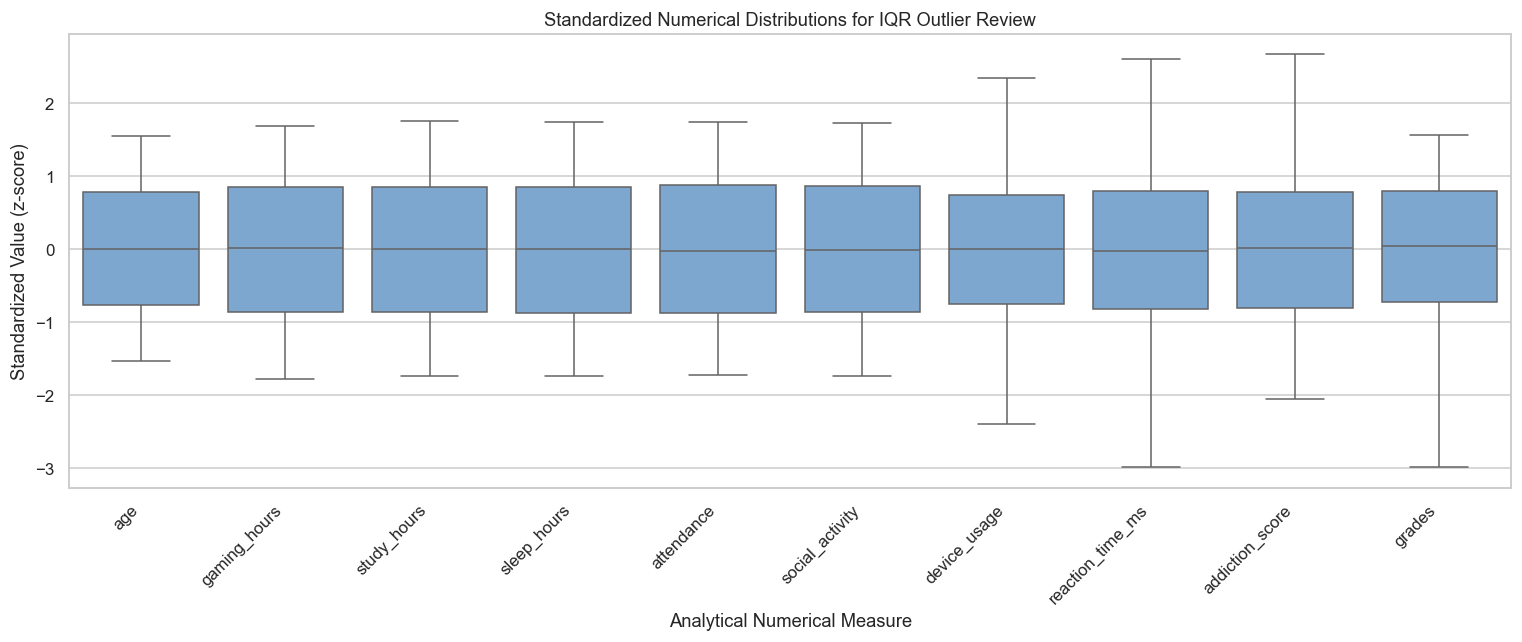

In [19]:
# Visualize comparable standardized distributions for the IQR assessment.
standardized_numeric = (
    (df[numeric_columns] - df[numeric_columns].mean())
    / df[numeric_columns].std()
)
standardized_long = standardized_numeric.melt(
    var_name="measure",
    value_name="standardized_value",
)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=standardized_long,
    x="measure",
    y="standardized_value",
    color="#6FA8DC",
)
plt.title("Standardized Numerical Distributions for IQR Outlier Review")
plt.xlabel("Analytical Numerical Measure")
plt.ylabel("Standardized Value (z-score)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**What it shows:** The standardized box plots place all ten analytical measures on a comparable
scale and visually support the IQR table.  
**What can be concluded:** The IQR method finds zero statistical outliers. The broad, bounded
distributions can legitimately produce this result, so all statistically valid observations
are kept.  
**Why it is useful:** It makes the crucial distinction visible: the 231 rows with domain-invalid
values were not detected by IQR. An invalid value is not the same thing as a statistical
outlier, and each requires a different decision rule.

### 3.7 Class imbalance

The original target, `grades`, is continuous, so this is a regression-style analysis and class
imbalance does not apply. It would matter for machine learning only if grades were converted
into classes, because a model could favor common classes and perform poorly on rare ones. The
bands below are created only to demonstrate the concept descriptively; they are not the
project's target.

In [20]:
# Create descriptive grade bands on valid-grade records only.
grade_band_labels = ["Fail (<50)", "Pass (50–64)", "Good (65–79)", "Excellent (80–100)"]
df_grade["grade_band"] = pd.cut(
    df_grade["grades"],
    bins=[-np.inf, 50, 65, 80, np.inf],
    labels=grade_band_labels,
    right=False,
)

grade_band_counts = df_grade["grade_band"].value_counts(sort=False)
grade_band_summary = pd.DataFrame(
    {
        "count": grade_band_counts,
        "percentage": df_grade["grade_band"]
        .value_counts(normalize=True, sort=False)
        .mul(100),
    }
)
display(grade_band_summary.round(2))

,count,percentage
grade_band,,
Fail (<50),1931,25.49
Pass (50–64),1678,22.15
Good (65–79),1733,22.87
Excellent (80–100),2235,29.50


**Decision:** The grade band is retained only in `df_grade` as a clearly labeled descriptive
aid; `grades` remains the continuous target.  
**Reason:** Any apparent imbalance in the displayed bands is partly an artifact of the chosen
cut points. Treating those derived bands as natural classes would change the analytical
question and discard information.

### 3.8 Data-quality decision log

In [21]:
# Consolidate evidence, decisions, affected rows, and reasons.
decision_log = pd.DataFrame(
    [
        {
            "Issue": "Original missing values",
            "Evidence": f"{int(missing['missing_count'].sum())} missing cells",
            "Decision": "No imputation or deletion",
            "Rows affected": 0,
            "Reason": "No treatment is supported by the data",
        },
        {
            "Issue": "Duplicate records",
            "Evidence": (
                f"{exact_duplicates} exact; {duplicates_without_id} without ID; "
                f"{duplicate_ids} duplicate IDs"
            ),
            "Decision": "Keep all rows",
            "Rows affected": 0,
            "Reason": "All duplicate checks are clean",
        },
        {
            "Issue": "Gender scope restriction",
            "Evidence": (
                f"{rows_removed_by_gender_scope} rows labelled 'Other' "
                f"of {rows_before_gender_scope} source rows"
            ),
            "Decision": "Keep Male and Female records only",
            "Rows affected": rows_removed_by_gender_scope,
            "Reason": (
                "Analysis scope is a two-group gender comparison; the excluded "
                "group is reported separately as a scope limitation"
            ),
        },
        {
            "Issue": "Semantic data types",
            "Evidence": "student_id stored as integer; 3 nominal object columns",
            "Decision": "ID → string; nominal columns → category",
            "Rows affected": len(df),
            "Reason": "Types should reflect analytical meaning",
        },
        {
            "Issue": "Invalid grades",
            "Evidence": f"{int(df['invalid_grade'].sum())} values outside 0–100",
            "Decision": "Flag, then set affected grades to NaN",
            "Rows affected": int(df["invalid_grade"].sum()),
            "Reason": "Avoid artificial capping and retain other valid fields",
        },
        {
            "Issue": "Invalid addiction scores",
            "Evidence": f"{int(df['invalid_addiction'].sum())} negative values",
            "Decision": "Flag, then set affected scores to NaN",
            "Rows affected": int(df["invalid_addiction"].sum()),
            "Reason": "Avoid artificial capping and retain other valid fields",
        },
        {
            "Issue": "Inconsistent categories",
            "Evidence": f"{int(category_consistency['hidden_variants'].sum())} hidden variants",
            "Decision": "Do not modify labels",
            "Rows affected": 0,
            "Reason": "Cleaning must be evidence-based",
        },
        {
            "Issue": "IQR statistical outliers",
            "Evidence": f"{int(outlier_summary['outlier_count'].sum())} outlier flags",
            "Decision": "Keep statistically valid observations",
            "Rows affected": 0,
            "Reason": "Bounded broad distributions legitimately have no IQR outliers",
        },
        {
            "Issue": "Class imbalance",
            "Evidence": "grades is a continuous target",
            "Decision": "Not applicable; bands are descriptive only",
            "Rows affected": 0,
            "Reason": "The project is regression-style, not classification",
        },
    ]
)
display(decision_log)

,Issue,Evidence,Decision,Rows affected,Reason
0,Original missing values,0 missing cells,No imputation or deletion,0,No treatment is supported by the data
1,Duplicate records,0 exact; 0 without ID; 0 duplicate IDs,Keep all rows,0,All duplicate checks are clean
2,Gender scope restriction,293 rows labelled 'Other' of 8000 source rows,Keep Male and Female records only,293,Analysis scope is a two-group gender compariso...
3,Semantic data types,student_id stored as integer; 3 nominal object...,ID → string; nominal columns → category,7707,Types should reflect analytical meaning
4,Invalid grades,130 values outside 0–100,"Flag, then set affected grades to NaN",130,Avoid artificial capping and retain other vali...
5,Invalid addiction scores,103 negative values,"Flag, then set affected scores to NaN",103,Avoid artificial capping and retain other vali...
6,Inconsistent categories,0 hidden variants,Do not modify labels,0,Cleaning must be evidence-based
7,IQR statistical outliers,0 outlier flags,Keep statistically valid observations,0,Bounded broad distributions legitimately have ...
8,Class imbalance,grades is a continuous target,Not applicable; bands are descriptive only,0,"The project is regression-style, not classific..."


The completed log shows that each transformation follows from explicit evidence. Clean checks
remain in the record instead of being skipped.

### Validation of cleaned data

In [22]:
# Recheck the cleaned working data and audit fields.
print("Raw source shape:", df_raw.shape)
print("Working shape (includes two audit flags):", df.shape)
print("\nMissing values after invalid-value marking:")
print(df.isna().sum())
print("\nExact duplicates:", int(df.duplicated().sum()))
print("\nCleaned grade range:", df["grades"].min(), "to", df["grades"].max())
print(
    "Cleaned addiction-score range:",
    df["addiction_score"].min(),
    "to",
    df["addiction_score"].max(),
)
print("\nCategories:")
for column in category_columns:
    print(column, list(df[column].cat.categories))

Raw source shape: (8000, 14)
Working shape (includes two audit flags): (7707, 16)

Missing values after invalid-value marking:
student_id             0
age                    0
gender                 0
gaming_hours           0
study_hours            0
sleep_hours            0
attendance             0
gaming_genre           0
social_activity        0
device_usage           0
reaction_time_ms       0
addiction_score      103
stress_level           0
grades               130
invalid_grade          0
invalid_addiction      0
dtype: int64

Exact duplicates: 0

Cleaned grade range: 0.0 to 100.0
Cleaned addiction-score range: 0.0 to 23.16

Categories:
gender ['Female', 'Male']
gaming_genre ['Casual', 'FPS', 'RPG']
stress_level ['High', 'Low', 'Medium']


The raw source had zero missing values. The working copy now has missing values only where 130
invalid grades and 103 invalid addiction scores were deliberately marked; all 7,707 in-scope
rows remain available for analyses that do not require those fields. The cleaned ranges now
respect the working domain rules, duplicate counts remain zero, and categorical labels remain
unchanged.

## Part 4 — Exploratory Data Analysis

### 4.1 Numerical analysis

The table combines standard descriptive statistics with the median and skewness. Counts differ
only where invalid grades or addiction scores were marked missing.

In [23]:
# Summarize valid analytical measures and add distribution shape.
numeric_summary = df_grade[numeric_columns].describe().T
numeric_summary["median"] = df_grade[numeric_columns].median()
numeric_summary["skewness"] = df_grade[numeric_columns].skew()
numeric_summary = numeric_summary[
    ["count", "mean", "std", "min", "25%", "median", "50%", "75%", "max", "skewness"]
]
display(numeric_summary.round(3))

,count,mean,std,min,25%,median,50%,75%,max,skewness
age,7577.0,19.979,2.591,16.00,18.00,20.000,20.000,22.00,24.00,-0.000
gaming_hours,7577.0,4.112,2.307,0.00,2.16,4.170,4.170,6.09,8.00,-0.068
study_hours,7577.0,5.413,2.558,1.00,3.21,5.390,5.390,7.57,10.00,0.039
sleep_hours,7577.0,6.478,1.440,4.00,5.23,6.490,6.490,7.71,9.00,0.015
attendance,7577.0,79.780,11.560,60.00,69.74,79.520,79.520,89.96,100.00,0.037
social_activity,7577.0,2.508,1.442,0.00,1.28,2.500,2.500,3.76,5.00,-0.001
device_usage,7577.0,7.606,2.706,1.10,5.59,7.640,7.640,9.60,13.95,-0.016
reaction_time_ms,7577.0,270.830,29.410,183.26,246.87,270.060,270.060,294.33,347.87,0.058
addiction_score,7476.0,10.103,4.902,0.00,6.18,10.160,10.160,13.97,23.16,0.023
grades,7577.0,65.531,21.988,0.00,49.55,66.531,66.531,83.24,100.00,-0.282


Valid grades average 65.531 with a median of 66.531 and a standard deviation of 21.988; their
skewness of −0.282 indicates only a mild left tail. Gaming time, study time, sleep, attendance,
device use, and valid addiction scores all have means close to their medians and skewness near
zero, consistent with broad, bounded, roughly symmetric distributions. This regularity is
analytically convenient but also supports caution about possible synthetic generation.

### 4.2 Categorical analysis

Counts and percentages describe the full working sample; grade summaries use only records with
valid grades.

In [24]:
# Display count and percentage tables for each categorical feature.
for column in category_columns:
    counts = df[column].value_counts(dropna=False)
    percentages = df[column].value_counts(
        normalize=True,
        dropna=False,
    ).mul(100)
    print(f"\n{column}")
    display(
        pd.DataFrame(
            {
                "count": counts,
                "percentage": percentages,
            }
        ).round(2)
    )


gender


,count,percentage
gender,,
Male,3904,50.66
Female,3803,49.34



gaming_genre


,count,percentage
gaming_genre,,
FPS,3076,39.91
RPG,2321,30.12
Casual,2310,29.97



stress_level


,count,percentage
stress_level,,
Medium,4086,53.02
Low,2645,34.32
High,976,12.66


In [25]:
# Compare valid grades across categorical groups.
categorical_grade_summaries = {}
categorical_mean_spans = {}
for column in category_columns:
    summary = (
        df_grade.groupby(column, observed=True)["grades"]
        .agg(["count", "mean", "median", "std"])
        .round(2)
    )
    categorical_grade_summaries[column] = summary
    categorical_mean_spans[column] = summary["mean"].max() - summary["mean"].min()
    print(f"\nGrades by {column}")
    display(summary)

print("\nMaximum minus minimum group mean:")
display(
    pd.Series(categorical_mean_spans, name="mean_grade_span")
    .to_frame()
    .round(2)
)


Grades by gender


,count,mean,median,std
gender,,,,
Female,3733,65.84,66.96,21.92
Male,3844,65.23,66.17,22.06



Grades by gaming_genre


,count,mean,median,std
gaming_genre,,,,
Casual,2256,65.55,66.59,22.28
FPS,3032,65.47,66.27,21.81
RPG,2289,65.60,66.90,21.94



Grades by stress_level


,count,mean,median,std
stress_level,,,,
High,954,80.49,81.64,13.03
Low,2610,49.84,47.04,21.20
Medium,4013,72.18,71.53,17.96



Maximum minus minimum group mean:


,mean_grade_span
gender,0.61
gaming_genre,0.13
stress_level,30.65


Gender means differ by only 0.61 points (65.23 for Male, 65.84 for Female), and gaming-genre
means range from 65.47 to 65.60; both differences are marginal beside within-group standard
deviations near 22. Stress groups differ much more descriptively: valid mean grades are 49.84
for Low, 72.18 for Medium, and 80.49 for High. This surprising order should not be treated as causal; it may reflect other
variables, an unusual encoding, or synthetic construction.

### 4.3 Relationship analysis

The correlation matrix uses analytical numerical columns only. Pandas computes each
correlation from rows where the relevant pair is valid.

In [26]:
# Calculate and display cleaned numerical associations.
analysis_columns = [
    "age",
    "gaming_hours",
    "study_hours",
    "sleep_hours",
    "attendance",
    "social_activity",
    "device_usage",
    "reaction_time_ms",
    "addiction_score",
    "grades",
]
correlation_matrix = df[analysis_columns].corr()
grade_correlations = (
    correlation_matrix["grades"]
    .drop("grades")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)
gaming_intercorrelations = correlation_matrix.loc[
    ["gaming_hours", "device_usage", "addiction_score", "reaction_time_ms"],
    ["gaming_hours", "device_usage", "addiction_score", "reaction_time_ms"],
]

print("Correlation matrix:")
display(correlation_matrix.round(3))
print("\nAssociations with grades, ranked by absolute magnitude:")
display(grade_correlations.to_frame("correlation_with_grades").round(3))
print("\nIntercorrelations among gaming-related measures:")
display(gaming_intercorrelations.round(3))

Correlation matrix:


,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
age,1.000,0.003,0.012,0.008,0.014,0.009,-0.000,-0.002,0.002,0.011
gaming_hours,0.003,1.000,-0.010,0.002,-0.002,0.009,0.848,-0.939,0.907,-0.554
study_hours,0.012,-0.010,1.000,0.017,-0.005,-0.009,-0.009,0.012,-0.003,0.725
sleep_hours,0.008,0.002,0.017,1.000,-0.026,-0.021,0.008,-0.009,-0.001,0.238
attendance,0.014,-0.002,-0.005,-0.026,1.000,0.009,-0.008,0.001,-0.001,0.128
social_activity,0.009,0.009,-0.009,-0.021,0.009,1.000,0.009,-0.009,0.015,-0.020
device_usage,-0.000,0.848,-0.009,0.008,-0.008,0.009,1.000,-0.792,0.842,-0.470
reaction_time_ms,-0.002,-0.939,0.012,-0.009,0.001,-0.009,-0.792,1.000,-0.847,0.520
addiction_score,0.002,0.907,-0.003,-0.001,-0.001,0.015,0.842,-0.847,1.000,-0.496
grades,0.011,-0.554,0.725,0.238,0.128,-0.020,-0.470,0.520,-0.496,1.000



Associations with grades, ranked by absolute magnitude:


,correlation_with_grades
study_hours,0.725
gaming_hours,-0.554
reaction_time_ms,0.520
addiction_score,-0.496
device_usage,-0.470
sleep_hours,0.238
attendance,0.128
social_activity,-0.020
age,0.011



Intercorrelations among gaming-related measures:


,gaming_hours,device_usage,addiction_score,reaction_time_ms
gaming_hours,1.000,0.848,0.907,-0.939
device_usage,0.848,1.000,0.842,-0.792
addiction_score,0.907,0.842,1.000,-0.847
reaction_time_ms,-0.939,-0.792,-0.847,1.000


In [27]:
# Cross-tabulate mean valid grades by stress level and gaming genre.
stress_genre_pivot = pd.pivot_table(
    df_grade,
    values="grades",
    index="stress_level",
    columns="gaming_genre",
    aggfunc="mean",
    observed=True,
)
display(stress_genre_pivot.round(2))

gaming_genre,Casual,FPS,RPG
stress_level,,,
High,81.79,80.19,79.49
Low,48.32,50.21,50.86
Medium,72.87,71.80,72.03


In [28]:
# Summarize valid grades across descriptive gaming-hour bands.
df_grade["gaming_hours_band"] = pd.cut(
    df_grade["gaming_hours"],
    bins=[-np.inf, 2, 4, 6, np.inf],
    labels=["0–<2", "2–<4", "4–<6", "6+"],
    right=False,
)
gaming_band_summary = (
    df_grade.groupby("gaming_hours_band", observed=True)["grades"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)
display(gaming_band_summary)

,count,mean,median,std
gaming_hours_band,,,,
0–<2,1765,81.39,82.72,15.36
2–<4,1841,72.02,72.12,17.36
4–<6,1975,61.75,60.21,18.90
6+,1996,49.26,47.10,21.35


Study hours have the strongest cleaned association with grades (`r = 0.725`), followed by
gaming hours (`r = −0.554`), reaction time (`r = 0.520`), addiction score (`r = −0.496`), and
device use (`r = −0.470`). Sleep (`r = 0.238`) and attendance (`r = 0.128`) are weaker positive
associations; age and social activity are essentially unrelated to grades in this sample.

The gaming-hour bands show the same descending descriptive pattern as gaming time increases.
However, gaming hours, device usage, addiction score, and reaction time move together strongly:
for example, gaming hours correlate 0.848 with device usage, 0.907 with addiction score, and
−0.939 with reaction time. These cannot be read as four independent effects. All results show
association, not causation; confounding, measurement design, and possible synthetic generation
remain plausible explanations.

## Part 5 — Data Visualization

The seven figures below use the same cleaned frames and consistent styling. Each is followed by
an interpretation covering what it shows, what can be concluded, and why it is useful.

### Figure 1 — Distribution of valid grades

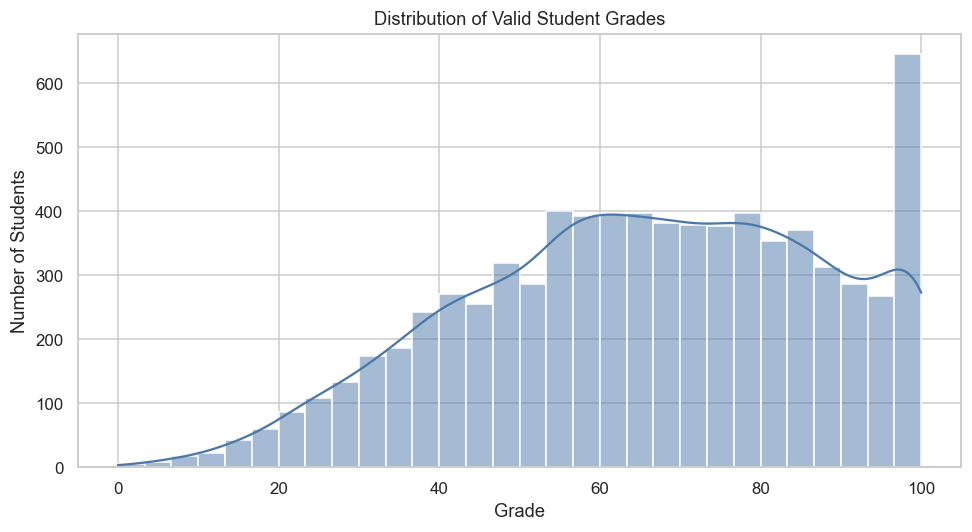

In [29]:
# Plot the valid target distribution.
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df_grade,
    x="grades",
    bins=30,
    kde=True,
    color="#4C78A8",
)
plt.title("Distribution of Valid Student Grades")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

**What it shows:** Valid grades span 0–100 and are broadly concentrated around the middle of
the scale, with mean 65.531, median 66.531, and mild negative skew (−0.282).  
**What can be concluded:** Academic performance varies substantially across the sample; the
distribution is not dominated by a narrow cluster or a severe skew.  
**Why it is useful:** The chart provides essential target context before interpreting
relationships or recommending support.

### Figure 2 — Grades by stress level

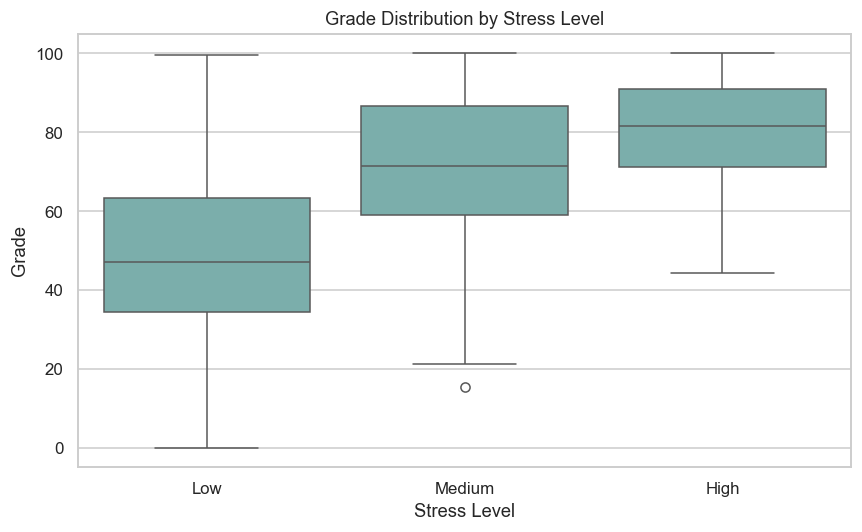

In [30]:
# Compare full grade distributions across ordered stress groups.
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_grade,
    x="stress_level",
    y="grades",
    order=["Low", "Medium", "High"],
    color="#72B7B2",
)
plt.title("Grade Distribution by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Grade")
plt.tight_layout()
plt.show()

**What it shows:** Grade distributions shift upward from Low to Medium to High stress; group
means are 49.84, 72.18, and 80.49 respectively.  
**What can be concluded:** The stress groups differ substantially and descriptively in this
dataset, but the chart cannot establish that stress improves grades.  
**Why it is useful:** The unexpected ordering flags a relationship that educators should
investigate and that the data team should validate against the source's stress encoding.

### Figure 3 — Study hours and grades

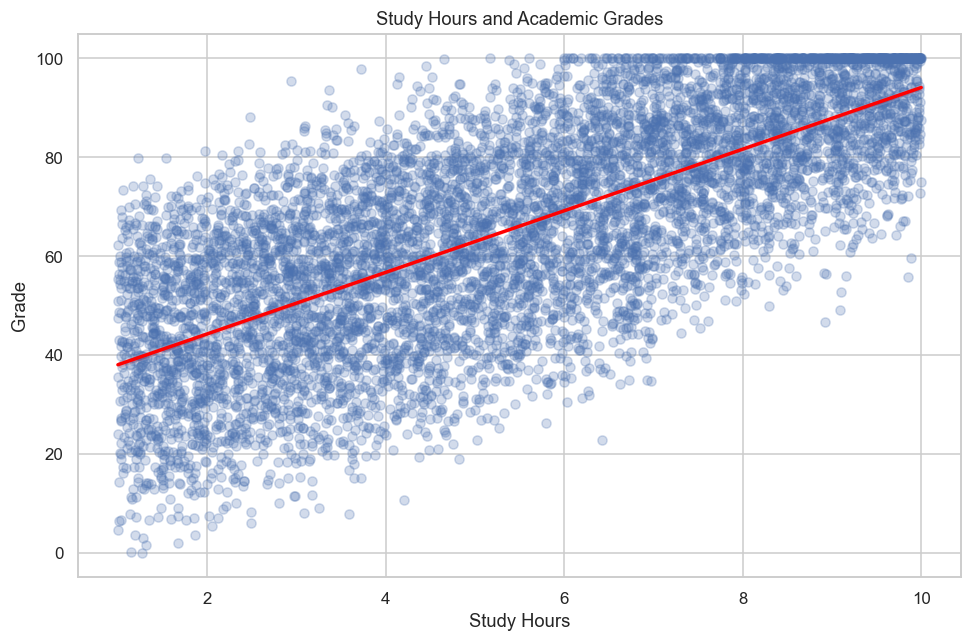

In [31]:
# Show the cleaned study-time association with a fitted trend.
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df_grade,
    x="study_hours",
    y="grades",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"},
)
plt.title("Study Hours and Academic Grades")
plt.xlabel("Study Hours")
plt.ylabel("Grade")
plt.tight_layout()
plt.show()

**What it shows:** The fitted line rises clearly as study hours increase, consistent with the
cleaned correlation of 0.725.  
**What can be concluded:** Students reporting more study time tend to have higher grades in
this sample; individual variation remains visible.  
**Why it is useful:** This is the strongest observed grade association and can help students
and academic advisors prioritize study planning while avoiding a causal claim.

### Figure 4 — Gaming hours and grades

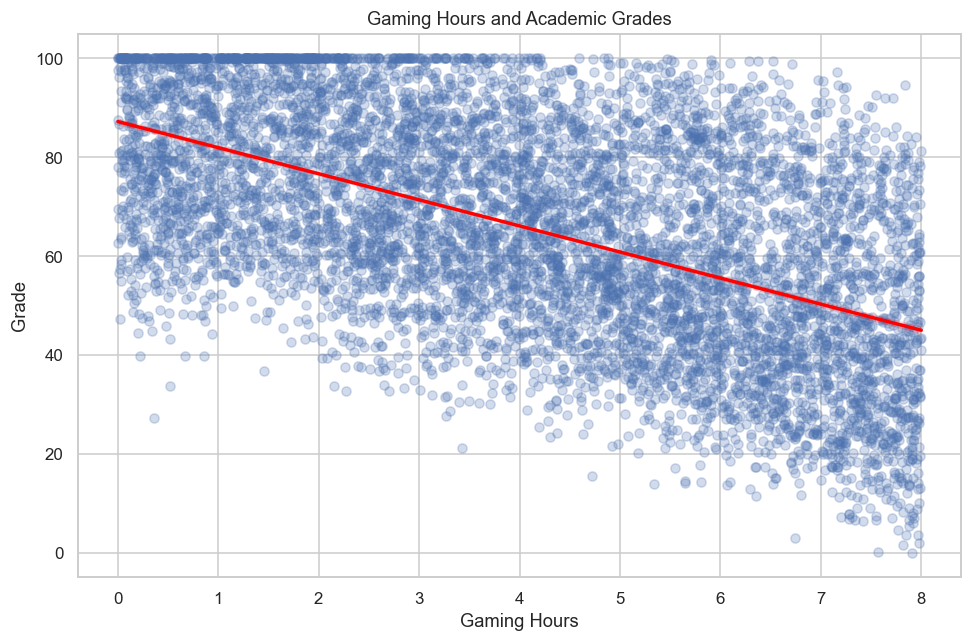

In [32]:
# Show the cleaned gaming-time association with a fitted trend.
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df_grade,
    x="gaming_hours",
    y="grades",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"},
)
plt.title("Gaming Hours and Academic Grades")
plt.xlabel("Gaming Hours")
plt.ylabel("Grade")
plt.tight_layout()
plt.show()

**What it shows:** The fitted line slopes downward, matching the cleaned correlation of −0.554
and the decreasing gaming-hour-band summaries.  
**What can be concluded:** Students with more gaming time tend to have lower grades in this
sample, but the relationship may overlap with device use, addiction score, study time, or
other factors.  
**Why it is useful:** It identifies a practical screening pattern for schedule discussions
without claiming that gaming itself causes lower grades.

### Figure 5 — Numerical correlation heatmap

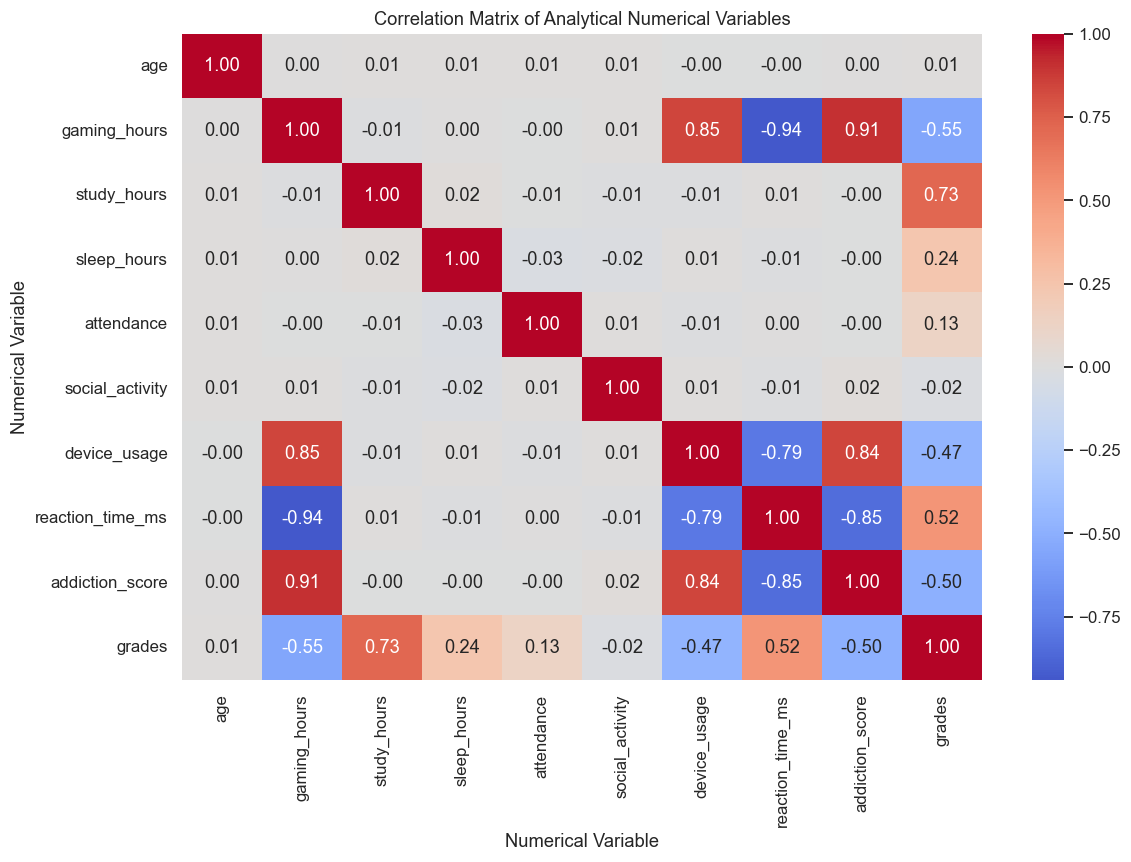

In [33]:
# Visualize cleaned pairwise correlations and interrelated predictors.
plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Correlation Matrix of Analytical Numerical Variables")
plt.xlabel("Numerical Variable")
plt.ylabel("Numerical Variable")
plt.tight_layout()
plt.show()

**What it shows:** The heatmap displays grade associations and the strong cluster connecting
gaming hours, device use, addiction score, and reaction time.  
**What can be concluded:** Study hours have the largest positive grade correlation, while
gaming hours have the largest negative one; the gaming-related measures are too
intercorrelated to interpret as independent effects.  
**Why it is useful:** It summarizes many relationships at once and warns analysts against
double-counting correlated signals in later modeling or policy conclusions.

### Figure 6 — Mean grade by gaming genre

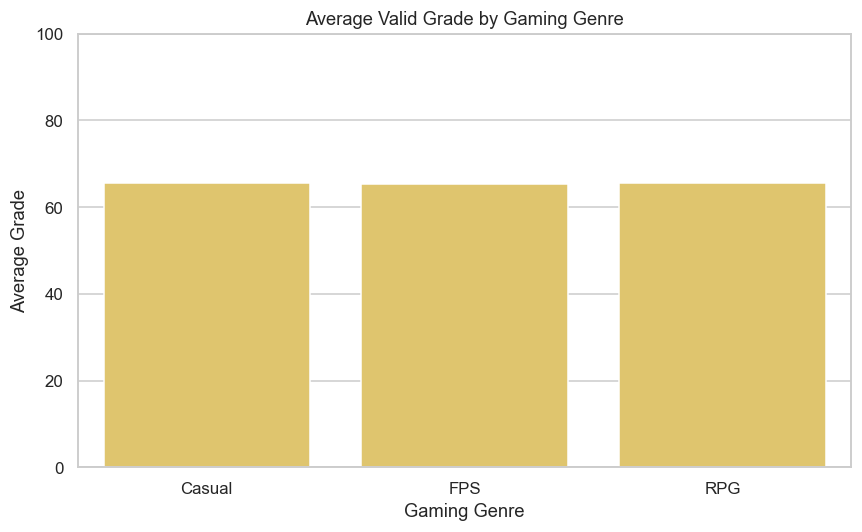

In [34]:
# Sort and compare genre-level mean valid grades.
genre_grades = (
    df_grade.groupby("gaming_genre", observed=True)["grades"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=genre_grades,
    x="gaming_genre",
    y="grades",
    color="#F2CF5B",
)
plt.title("Average Valid Grade by Gaming Genre")
plt.xlabel("Gaming Genre")
plt.ylabel("Average Grade")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**What it shows:** RPG, Casual, and FPS mean grades are 65.60, 65.55, and 65.47—less than
0.2 points apart.  
**What can be concluded:** Genre groups do not differ meaningfully in average grades in this
sample.  
**Why it is useful:** The near-equality discourages unsupported interventions or stereotypes
based on a student's preferred game genre.

### Figure 7 — Device usage and grades

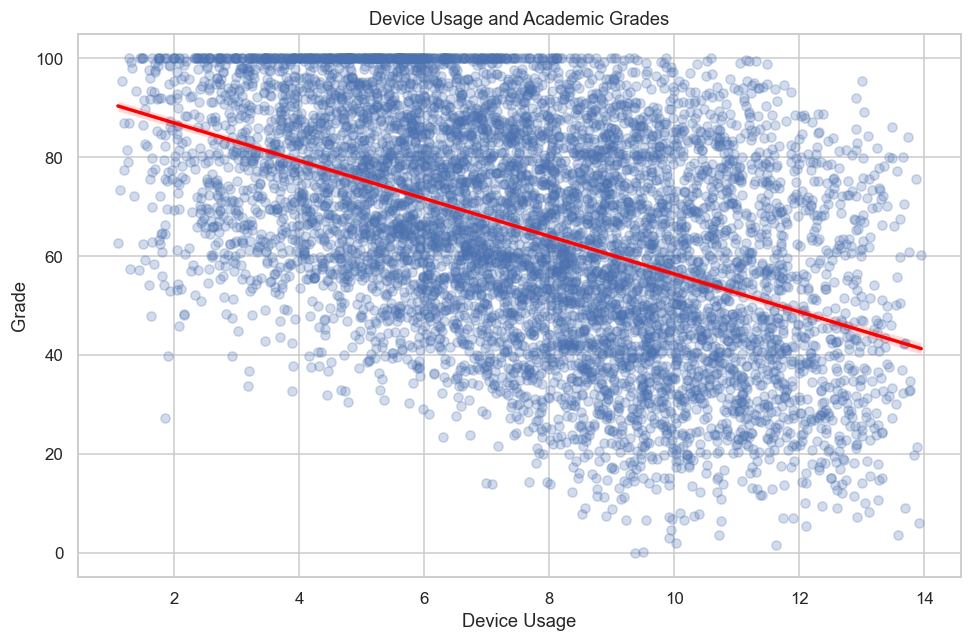

In [35]:
# Show the cleaned overall-device-use association with a fitted trend.
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df_grade,
    x="device_usage",
    y="grades",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"},
)
plt.title("Device Usage and Academic Grades")
plt.xlabel("Device Usage")
plt.ylabel("Grade")
plt.tight_layout()
plt.show()

**What it shows:** The fitted line declines as device usage increases, consistent with the
cleaned correlation of −0.470.  
**What can be concluded:** Students with higher device-use values tend to have lower grades in
this sample, but device use overlaps strongly with gaming hours (`r = 0.848`).  
**Why it is useful:** The broader device measure may help advisors discuss total screen-time
patterns, while the overlap cautions against treating it as a separate causal driver.

## Part 6 — Key Insights

1. **Study time:** Study hours have the strongest observed grade association (`r = 0.725`).
   Students reporting more study time tend to have higher grades, making structured study
   planning the clearest descriptive opportunity for students and advisors; the cross-sectional
   data still cannot establish causation.
2. **Gaming time:** Gaming hours are moderately negatively associated with grades
   (`r = −0.554`), and mean/median grades decline across the displayed gaming-hour bands.
   Schedule balance is therefore worth discussing, but gaming should not be labeled the cause
   of lower performance.
3. **Sleep:** Sleep has a smaller positive association with grades (`r = 0.238`). Consistent
   sleep may be a useful support factor, yet it is much less informative here than study or
   gaming time and should not be oversold.
4. **Attendance:** Attendance is weakly positively associated with grades (`r = 0.128`).
   Educators can continue monitoring attendance as one contextual signal, but it is not a
   strong standalone indicator in this dataset.
5. **Overall device usage:** Device use has a moderate negative grade association
   (`r = −0.470`). Students with higher values tend to have lower grades, although its strong
   overlap with gaming time limits any independent interpretation.
6. **Addiction score:** Among records where both fields are valid, addiction score is
   negatively associated with grades (`r = −0.496`). Counselors may treat this as a screening
   clue, not a diagnosis, especially because the score's construction and scale are
   undocumented.
7. **Reaction time:** Reaction time has a positive association with grades (`r = 0.520`), so
   higher millisecond values—normally interpreted as slower responses—coincide with higher
   grades here. This counterintuitive result should prompt definition and provenance checks
   before stakeholder action.
8. **Gender comparison:** Within the Male/Female analysis scope, mean valid grades are 65.84
   for Female and 65.23 for Male—a gap of only 0.61 points compared with within-group standard
   deviations near 22. Gender-based academic interventions are not supported by this
   descriptive difference, and the excluded `Other` group is outside the scope of this claim.
9. **Genre comparison:** RPG, Casual, and FPS mean grades span only 65.47–65.60. Preferred
   genre adds little descriptive separation, so stakeholders should avoid genre-based
   assumptions.
10. **Stress level:** Mean valid grades rise from 49.84 in Low stress to 72.18 in Medium and
    80.49 in High. The groups clearly differ descriptively, but the unexpected direction may
    reflect encoding, confounding, or synthetic design and requires validation rather than a
    recommendation to increase stress.
11. **Age and social activity:** Age (`r = 0.011`) and social activity (`r = −0.020`) have
    essentially no linear association with grades. They offer little basis for prioritizing
    students in this sample, though nonlinear relationships were not tested.
12. **Intercorrelated gaming measures:** Gaming hours correlate 0.848 with device use, 0.907
    with addiction score, and −0.939 with reaction time. These variables move as a cluster,
    so interpreting them as independent effects would overstate what the EDA establishes.
13. **Data quality and generalizability:** The source has zero original missing cells, zero
    duplicate records, and zero IQR outliers, yet 231 in-scope rows violate at least one domain
    rule. This proves that invalid values can escape statistical outlier checks and, together
    with unresolved provenance and the Male/Female scope restriction, limits confidence beyond
    this dataset.

## Part 7 — Business / Stakeholder Recommendations

1. **Students:** Use a balanced weekly schedule that protects study time while setting
   intentional gaming limits. Figures 3 and 4 and Insights 1–2 support discussing both
   behaviors together, without claiming that either behavior alone determines grades.
2. **Academic advisors:** Screen for the combined pattern of low study time, high gaming time,
   and high device use rather than relying on one threshold. Figure 5 and Insight 12 show that
   the gaming-related measures are strongly intercorrelated.
3. **Educators:** Continue encouraging regular sleep and attendance as supportive habits, but
   treat them as secondary signals. Insights 3–4 show positive but comparatively weak
   associations, so intensive action based on either measure alone is not justified.
4. **School counselors:** When high gaming time aligns with a high addiction score, offer a
   non-stigmatizing conversation or further validated assessment. Insight 6 supports screening,
   while the undocumented score definition requires restraint and rules out diagnostic use.
5. **Educators and advisors:** Do not target academic interventions by gender or preferred
   gaming genre. Figure 6 and Insights 8–9 show only marginal differences relative to
   within-group variation. This guidance covers Male and Female students only.
6. **Data collection team:** Add entry validation that rejects grades above 100 and negative
   addiction scores, preserve audit flags, and document the addiction scale, reaction-time
   meaning, time windows, original source URL, and data dictionary. The Part 3 decision log and
   Insight 13 directly support this quality-control change.
7. **Research and data collection teams:** Collect repeated measurements across semesters,
   including baseline achievement and relevant contextual factors, before making any causal
   claim. The cross-sectional correlations in Figure 5 establish association only; longitudinal
   design is needed to evaluate temporal order and within-student change.

## Part 8 — Reflection

### Most challenging data-quality problem

The most challenging problem was recognizing that a dataset with no missing values,
duplicates, or IQR outliers could still contain invalid observations. Grades above 100 and
negative addiction scores forced me to distinguish domain validity from statistical rarity
instead of assuming that an automated outlier rule would find every problem.

### Decision requiring the most critical thinking

The decision that required the most thought was how to treat invalid target and score values
without damaging unrelated information. I chose to flag first, replace only the offending
cells with missing values, and filter per analysis. This preserved valid sleep, attendance,
and behavior data while avoiding artificial boundary spikes from capping.

### Most interesting finding

I found the combination of a strong positive study-hours association and the unexpected
stress-level ordering most interesting. The first pattern is intuitive, while the second is a
reminder that a striking descriptive difference may reflect encoding, confounding, or data
generation rather than a causal relationship.

### What I would do differently next time

Next time I would secure the original source page, data dictionary, scale definitions. I would also plan longitudinal collection across several
semesters and preregister key validation rules so that causal questions and measurement
ambiguities are addressed at the design stage.

### What I learned about EDA

I learned that good EDA is measured by the quality of its evidence and justifications, not by
the number of transformations. Refusing to invent missing-value or duplicate treatments was as
important as making changes. I also learned to keep invalid values distinct from outliers,
preserve auditability, and phrase correlations as associations rather than proof of cause.